In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('C:\\Users\\krask\\Documents\\Project_places_to_visit\\last_user_reviews.csv')
df

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1,el,Впечатляющий музей с экспонатами российской ко...,ru
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-09-20,1,en,Очень насыщенная и красивая выставка космическ...,ru
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru,Павильон был построен в 1938—1939 годах и носи...,ru
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-03-10,1,ru,"Как музей весьма средне, а как место, где можн...",ru
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-04-10,1,ru,Абсолютно стоит потраченных денег. Очень много...,ru
...,...,...,...,...,...,...,...,...
299023,Nick “Furi? Kuri!”,5,"Отличное место! Очень радует, что в этом район...",2020-11-04,886,ru,"Отличное место! Очень радует, что в этом район...",ru
299024,Паша Латышенок,5,"Хорошо уютное заведение, очень вежливый персон...",2020-09-25,886,ru,"Хорошо уютное заведение, очень вежливый персон...",ru
299025,Екатерина «Katierra» Шевич,5,Любимое место уже не первый год.\nЗаказываю бе...,NaN,886,ru,Любимое место уже не первый год.\nЗаказываю бе...,ru
299026,Надежда Осипова,5,Праздновали день рождения) никому не говорили ...,NaN,886,ru,Праздновали день рождения) никому не говорили ...,ru


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
import pandas as pd
from tqdm import tqdm
import os
import ast

class AtmosphereProcessor:
    """Класс для обработки датасета моделью"""
    
    def __init__(self, model_path="./atmosphere_model_best", device=None):
        """
        Инициализация модели
        
        Args:
            model_path: путь к папке с моделью
            device: 'cuda' или 'cpu'
        """
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        
        print(f" Загрузка модели из: {model_path}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(model_path)
        self.model = self.model.to(self.device)
        self.model.eval()
        
        self.id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}
        print(f" Модель загружена на {self.device}")
    
    def extract_atmosphere(self, text):
        """
        Извлекает фразы атмосферы из текста
        
        Args:
            text: строка текста
        
        Returns:
            строка с фразами через запятую (или пустая строка)
        """
        if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
            return ""
        
        try:
            # Токенизация
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=512,
                return_offsets_mapping=True
            )
            
            offsets = inputs['offset_mapping'][0]
            inputs.pop('offset_mapping')
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            
            with torch.no_grad():
                outputs = self.model(**inputs)
                predictions = torch.argmax(outputs.logits, dim=2)[0]
            
            tokens = self.tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
            
            # Восстанавливаем слова
            words_with_labels = []
            current_word = ""
            current_label = None
            last_end = 0
            
            for token, pred, (start, end) in zip(tokens, predictions, offsets):
                if start == end or token in ['[CLS]', '[SEP]', '[PAD]']:
                    continue
                
                pred_label = self.id_to_label[pred.item()]
                fragment = text[start:end]
                
                if start > last_end and current_word:
                    if current_label in ['B-AMBIENCE', 'I-AMBIENCE']:
                        words_with_labels.append((current_word, current_label))
                    current_word = ""
                    current_label = None
                
                current_word += fragment
                
                if pred_label == 'B-AMBIENCE':
                    current_label = 'B-AMBIENCE'
                elif pred_label == 'I-AMBIENCE' and current_label != 'B-AMBIENCE':
                    current_label = 'I-AMBIENCE'
                
                last_end = end
            
            if current_word and current_label in ['B-AMBIENCE', 'I-AMBIENCE']:
                words_with_labels.append((current_word, current_label))
            
            # Формируем фразы
            phrases = []
            current_phrase = []
            
            for word, label in words_with_labels:
                if label == 'B-AMBIENCE':
                    if current_phrase:
                        phrases.append(' '.join(current_phrase))
                    current_phrase = [word]
                elif label == 'I-AMBIENCE' and current_phrase:
                    current_phrase.append(word)
                else:
                    if current_phrase:
                        phrases.append(' '.join(current_phrase))
                        current_phrase = []
            
            if current_phrase:
                phrases.append(' '.join(current_phrase))
            
            # Убираем дубликаты и возвращаем строку через запятую
            unique_phrases = list(dict.fromkeys(phrases))
            return ', '.join(unique_phrases) if unique_phrases else ""
            
        except Exception as e:
            print(f"Ошибка при обработке текста: {text[:50]}... Error: {e}")
            return ""
    
    def process_dataframe(self, df, text_column, output_column="atmosphere_tags", 
                          batch_size=32, save_intermediate=True, intermediate_path="intermediate_results.csv"):
        """
        Обрабатывает DataFrame, добавляя столбец с тегами атмосферы
        
        Args:
            df: pandas DataFrame
            text_column: название колонки с текстом
            output_column: название новой колонки для результатов
            batch_size: размер батча для обработки
            save_intermediate: сохранять ли промежуточные результаты
            intermediate_path: путь для сохранения промежуточных результатов
        
        Returns:
            DataFrame с добавленным столбцом
        """
        print(f"\n{'='*60}")
        print("ОБРАБОТКА ДАТАСЕТА")
        print(f"{'='*60}")
        print(f" Всего строк: {len(df)}")
        print(f" Колонка с текстом: {text_column}")
        print(f"  Новая колонка: {output_column}")
        print(f"  Batch size: {batch_size}")
        
        # Проверяем существование колонки
        if text_column not in df.columns:
            raise ValueError(f"Колонка '{text_column}' не найдена. Доступные: {df.columns.tolist()}")
        
        # Создаем копию DataFrame
        result_df = df.copy()
        
        # Инициализируем новый столбец пустыми строками
        result_df[output_column] = ""
        
        # Собираем все результаты в список
        all_results = []
        
        # Обрабатываем батчами
        for start_idx in tqdm(range(0, len(df), batch_size), desc="Обработка"):
            end_idx = min(start_idx + batch_size, len(df))
            batch_texts = df[text_column].iloc[start_idx:end_idx]
            
            batch_results = []
            for text in batch_texts:
                phrases_str = self.extract_atmosphere(text)
                batch_results.append(phrases_str)
            
            all_results.extend(batch_results)
            
            # Промежуточное сохранение
            if save_intermediate:
                temp_df = result_df.copy()
                temp_df[output_column] = all_results + [""] * (len(df) - len(all_results))
                temp_df.to_csv(intermediate_path, index=False, encoding='utf-8')
        
        result_df[output_column] = all_results
        
        total_with_atmosphere = sum(1 for val in result_df[output_column] if val and val.strip())
        avg_phrases = sum(len(val.split(', ')) for val in result_df[output_column] if val) / len(df) if len(df) > 0 else 0
        
        # Собираем все уникальные фразы
        all_phrases = []
        for val in result_df[output_column]:
            if val:
                all_phrases.extend([p.strip() for p in val.split(', ')])
        
        print(f"\n СТАТИСТИКА ОБРАБОТКИ:")
        print(f"   Всего строк с атмосферой: {total_with_atmosphere} ({total_with_atmosphere/len(df)*100:.1f}%)")
        print(f"   Среднее количество фраз на строку: {avg_phrases:.2f}")
        print(f"   Всего уникальных фраз: {len(set(all_phrases))}")
        
        return result_df
    
    def process_and_save(self, df, text_column, output_column="atmosphere_tags", 
                         output_path="processed_dataset.csv", **kwargs):
        """
        Обрабатывает DataFrame и сохраняет результат в файл
        
        Args:
            df: pandas DataFrame
            text_column: колонка с текстом
            output_column: колонка для результатов
            output_path: путь для сохранения результата
            **kwargs: дополнительные параметры для process_dataframe
        """
        result_df = self.process_dataframe(df, text_column, output_column, **kwargs)
        result_df.to_csv(output_path, index=False, encoding='utf-8')
        print(f"\n Результат сохранен в: {output_path}")
        return result_df


# ==================== ПРОСТАЯ ФУНКЦИЯ ДЛЯ БЫСТРОГО ПРИМЕНЕНИЯ ====================

def add_atmosphere_column(input_csv, text_column, output_csv=None, model_path="./atmosphere_model_best"):
    """
    Простая функция для добавления колонки с атмосферой в CSV файл
    
    Args:
        input_csv: путь к входному CSV файлу
        text_column: название колонки с текстом
        output_csv: путь для сохранения (если None, то input_csv + '_with_atmosphere.csv')
        model_path: путь к модели
    """
    # Проверяем входной файл
    if not os.path.exists(input_csv):
        print(f" Файл {input_csv} не найден!")
        return None
    
    # Загружаем данные
    print(f" Загрузка {input_csv}...")
    df = pd.read_csv(input_csv)
    print(f" Загружено {len(df)} строк")
    print(f" Доступные колонки: {df.columns.tolist()}")
    
    # Проверяем наличие колонки
    if text_column not in df.columns:
        print(f"\n Колонка '{text_column}' не найдена!")
        print(f"Доступные колонки: {df.columns.tolist()}")
        return None
    
    # Загружаем модель
    processor = AtmosphereProcessor(model_path)
    
    # Определяем выходной файл
    if output_csv is None:
        output_csv = input_csv.replace('.csv', '_with_atmosphere.csv')
    
    # Обрабатываем
    result_df = processor.process_and_save(
        df=df,
        text_column=text_column,
        output_column="atmosphere_tags",
        output_path=output_csv
    )
    
    # Показываем примеры
    print("\n" + "="*60)
    print("ПРИМЕРЫ РЕЗУЛЬТАТОВ")
    print("="*60)
    
    samples = result_df[result_df['atmosphere_tags'] != ""].head(10)
    if len(samples) > 0:
        for idx, row in samples.iterrows():
            text_preview = row[text_column][:80] + "..." if len(str(row[text_column])) > 80 else row[text_column]
            print(f"\n Текст: {text_preview}")
            print(f"     Атмосфера: {row['atmosphere_tags']}")
    else:
        print("\n Не найдено строк с атмосферой. Проверьте модель и данные.")
    
    print(f"\n Готово! Результат сохранен в {output_csv}")
    return result_df


# ==================== ЗАПУСК ДЛЯ ВАШЕГО ФАЙЛА ====================

print("="*60)
print("ЗАПУСК ОБРАБОТКИ ДАТАСЕТА")
print("="*60)

# Ваш вызов функции
result = add_atmosphere_column(
    input_csv="last_user_reviews.csv",
    text_column="Перевод (Google)",
    output_csv="dataset_with_atmosphere.csv"
)

# Если хотите посмотреть на результаты
if result is not None:
    print("\n" + "="*60)
    print("ПЕРВЫЕ 5 СТРОК РЕЗУЛЬТАТА")
    print("="*60)
    print(result[['Перевод (Google)', 'atmosphere_tags']].head())
    
    # Сохраняем также в Excel если нужно
    # result.to_excel("dataset_with_atmosphere.xlsx", index=False)

ЗАПУСК ОБРАБОТКИ ДАТАСЕТА
📂 Загрузка last_user_reviews.csv...
📊 Загружено 299028 строк
📋 Доступные колонки: ['Name', 'Rating', 'Description', 'When', 'place_id', 'language', 'Перевод (Google)', 'check_lang']
📁 Загрузка модели из: ./atmosphere_model_best


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12666.61it/s]

✅ Модель загружена на cpu

ОБРАБОТКА ДАТАСЕТА
📊 Всего строк: 299028
📝 Колонка с текстом: Перевод (Google)
🏷️  Новая колонка: atmosphere_tags
⚙️  Batch size: 32



Обработка: 100%|██████████| 9345/9345 [7:56:17<00:00,  3.06s/it]   



📊 СТАТИСТИКА ОБРАБОТКИ:
   Всего строк с атмосферой: 165574 (55.4%)
   Среднее количество фраз на строку: 1.03
   Всего уникальных фраз: 89722

✅ Результат сохранен в: dataset_with_atmosphere.csv

ПРИМЕРЫ РЕЗУЛЬТАТОВ

📝 Текст: Впечатляющий музей с экспонатами российской космической программы.\nОт спутников...
   🏷️  Атмосфера: Впечатляющий величину,

📝 Текст: Очень насыщенная и красивая выставка космических достижений СССР. 
   🏷️  Атмосфера: насыщенная, красивая

📝 Текст: Павильон был построен в 1938—1939 годах и носил название «Механизация и электриф...
   🏷️  Атмосфера: космические аппараты, техника музей.

📝 Текст: Как музей весьма средне, а как место, где можно развлечь себя или детей хорошо. ...
   🏷️  Атмосфера: Фантастические миры, прикольное развлечение, «экскурсия»,, (темные стены,, световые проекции)

📝 Текст: Абсолютно стоит потраченных денег. Очень много инсталляций, есть интерактивные э...
   🏷️  Атмосфера: интерактивные экраны

📝 Текст: Павильон №34 «Центр Космонавтики 

АНАЛИЗ ПОКРЫТИЯ ДАТАСЕТА ТЕГАМИ АТМОСФЕРЫ

📊 ОБЩАЯ ИНФОРМАЦИЯ:
   Всего записей в датасете: 299028

🏷️ КОЛОНКА 'atmosphere_tags':
   • Есть теги: 165574 (55.4%)
   • Нет тегов: 133454 (44.6%)

📈 СТАТИСТИКА ПО КОЛИЧЕСТВУ ТЕГОВ:
   • Среднее количество тегов: 1.05
   • Медианное количество: 1
   • Максимум тегов: 16
   • Минимум (среди непустых): 1


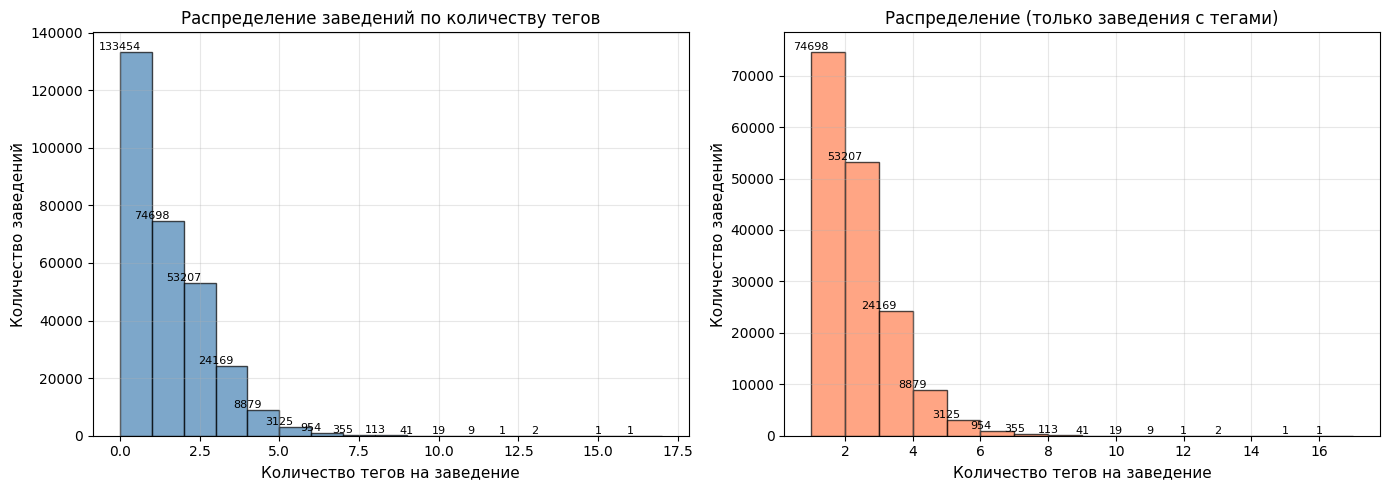

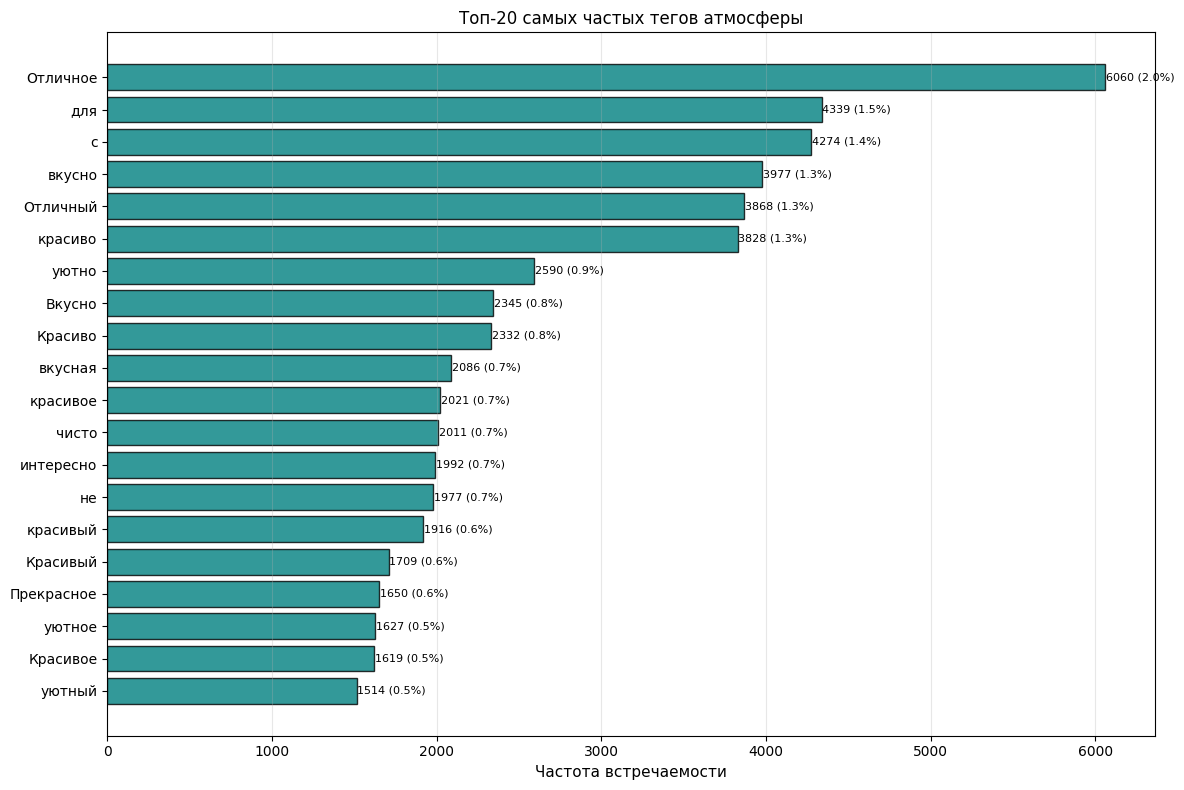

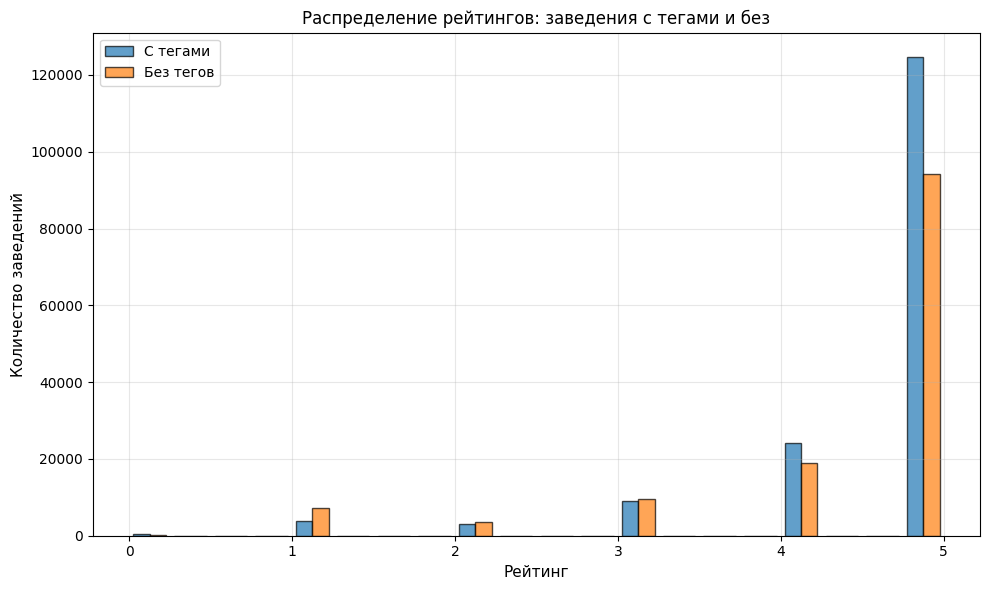


⭐ СРЕДНИЙ РЕЙТИНГ:
   • Заведения с тегами: 4.58
   • Заведения без тегов: 4.41

ИТОГОВОЕ ЗАКЛЮЧЕНИЕ
❌ Низкое покрытие: только 55.4% заведений имеют теги.
⚠️ Среднее количество тегов на заведение низкое (1.1).


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Загрузка датасета
df = pd.read_csv('dataset_with_atmosphere.csv')

print("="*60)
print("АНАЛИЗ ПОКРЫТИЯ ДАТАСЕТА ТЕГАМИ АТМОСФЕРЫ")
print("="*60)

# Базовая информация
print(f"\n📊 ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   Всего записей в датасете: {len(df)}")

# Проверка колонки atmosphere_tags
if 'atmosphere_tags' in df.columns:
    # Считаем пустые значения
    df['atmosphere_tags'] = df['atmosphere_tags'].fillna('')
    has_tags = df['atmosphere_tags'] != ''
    non_empty = has_tags.sum()
    
    print(f"\n🏷️ КОЛОНКА 'atmosphere_tags':")
    print(f"   • Есть теги: {non_empty} ({non_empty/len(df)*100:.1f}%)")
    print(f"   • Нет тегов: {len(df)-non_empty} ({(len(df)-non_empty)/len(df)*100:.1f}%)")
    
    # Статистика по количеству тегов на запись
    df['tags_count'] = df['atmosphere_tags'].apply(
        lambda x: len([t for t in x.split(',') if t.strip()]) if x else 0
    )
    
    print(f"\n📈 СТАТИСТИКА ПО КОЛИЧЕСТВУ ТЕГОВ:")
    print(f"   • Среднее количество тегов: {df['tags_count'].mean():.2f}")
    print(f"   • Медианное количество: {df['tags_count'].median():.0f}")
    print(f"   • Максимум тегов: {df['tags_count'].max()}")
    print(f"   • Минимум (среди непустых): 1")
    
    # ========== ГИСТОГРАММА 1: Распределение по количеству тегов ==========
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма 1a: все записи (включая нули)
    tags_data = df['tags_count']
    bins = range(0, tags_data.max() + 2)
    
    axes[0].hist(tags_data, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Количество тегов на заведение', fontsize=11)
    axes[0].set_ylabel('Количество заведений', fontsize=11)
    axes[0].set_title('Распределение заведений по количеству тегов', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Добавляем подписи над столбцами
    for i in range(tags_data.max() + 1):
        count = (tags_data == i).sum()
        if count > 0:
            axes[0].text(i, count + 5, str(count), ha='center', va='bottom', fontsize=8)
    
    # Гистограмма 1b: только записи с тегами (без нулей)
    tags_data_nonzero = tags_data[tags_data > 0]
    bins_nonzero = range(1, tags_data.max() + 2)
    
    axes[1].hist(tags_data_nonzero, bins=bins_nonzero, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Количество тегов на заведение', fontsize=11)
    axes[1].set_ylabel('Количество заведений', fontsize=11)
    axes[1].set_title('Распределение (только заведения с тегами)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    for i in range(1, tags_data.max() + 1):
        count = (tags_data == i).sum()
        if count > 0:
            axes[1].text(i, count + 2, str(count), ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # ========== ГИСТОГРАММА 2: Топ самых частых тегов ==========
    # Сбор всех тегов
    all_tags = []
    for tags in df[df['tags_count'] > 0]['atmosphere_tags']:
        for tag in str(tags).split(','):
            tag = tag.strip()
            if tag:
                all_tags.append(tag)
    
    tag_counter = Counter(all_tags)
    top_tags = tag_counter.most_common(20)
    top_tags_names = [t[0] for t in top_tags]
    top_tags_counts = [t[1] for t in top_tags]
    
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    
    # Горизонтальная гистограмма для топ-тегов
    y_pos = np.arange(len(top_tags_names))
    bars = ax2.barh(y_pos, top_tags_counts, color='teal', alpha=0.8, edgecolor='black')
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_tags_names, fontsize=10)
    ax2.set_xlabel('Частота встречаемости', fontsize=11)
    ax2.set_title('Топ-20 самых частых тегов атмосферы', fontsize=12)
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Добавляем значения
    for i, (bar, count) in enumerate(zip(bars, top_tags_counts)):
        ax2.text(count + 5, bar.get_y() + bar.get_height()/2, 
                f'{count} ({count/len(df)*100:.1f}%)', 
                va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # ========== АНАЛИЗ ПО РЕЙТИНГУ ==========
    if 'Rating' in df.columns:
        df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
        
        fig3, ax3 = plt.subplots(figsize=(10, 6))
        
        # Группируем по наличию тегов
        has_tags_group = df[df['tags_count'] > 0]['Rating'].dropna()
        no_tags_group = df[df['tags_count'] == 0]['Rating'].dropna()
        
        ax3.hist([has_tags_group, no_tags_group], bins=20, alpha=0.7, 
                label=['С тегами', 'Без тегов'], edgecolor='black')
        ax3.set_xlabel('Рейтинг', fontsize=11)
        ax3.set_ylabel('Количество заведений', fontsize=11)
        ax3.set_title('Распределение рейтингов: заведения с тегами и без', fontsize=12)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n⭐ СРЕДНИЙ РЕЙТИНГ:")
        print(f"   • Заведения с тегами: {has_tags_group.mean():.2f}")
        print(f"   • Заведения без тегов: {no_tags_group.mean():.2f}")
    
    # ========== ИТОГОВОЕ ЗАКЛЮЧЕНИЕ ==========
    print(f"\n{'='*60}")
    print(f"ИТОГОВОЕ ЗАКЛЮЧЕНИЕ")
    print(f"{'='*60}")
    
    coverage = non_empty / len(df) * 100
    if coverage == 100:
        print(f"✅ Отлично! Теги есть у 100% заведений.")
    elif coverage >= 90:
        print(f"✅ Хорошее покрытие: {coverage:.1f}% заведений имеют теги.")
    elif coverage >= 70:
        print(f"⚠️ Среднее покрытие: {coverage:.1f}% заведений имеют теги.")
    else:
        print(f"❌ Низкое покрытие: только {coverage:.1f}% заведений имеют теги.")
    
    if df['tags_count'].mean() < 2:
        print(f"⚠️ Среднее количество тегов на заведение низкое ({df['tags_count'].mean():.1f}).")
    else:
        print(f"✅ Среднее количество тегов на заведение: {df['tags_count'].mean():.1f}")
    
else:
    print(f"\n❌ Колонка 'atmosphere_tags' не найдена в датасете.")
    print(f"   Доступные колонки: {list(df.columns)}")

In [5]:
import pandas as pd
df = pd.read_csv('dataset_with_atmosphere.csv')
df

,Name,Rating,Description,When,place_id,language,Перевод (Google),check_lang,atmosphere_tags
0,Andreas Pantelis Moursellas,5,Εντυπωσιακό μουσείο με εκθέματα από το διαστημ...,NaN,1,el,Впечатляющий музей с экспонатами российской ко...,ru,"Впечатляющий величину,"
1,Krasen Hristov,5,Very rich and beautiful exhibition of the USSR...,2025-09-20,1,en,Очень насыщенная и красивая выставка космическ...,ru,"насыщенная, красивая"
2,Antonius,5,Павильон был построен в 1938—1939 годах и носи...,2024-11-23,1,ru,Павильон был построен в 1938—1939 годах и носи...,ru,"космические аппараты, техника музей."
3,Bulushova Lidiya,4,"Как музей весьма средне, а как место, где можн...",2025-03-10,1,ru,"Как музей весьма средне, а как место, где можн...",ru,"Фантастические миры, прикольное развлечение, «..."
4,Максим,5,Абсолютно стоит потраченных денег. Очень много...,2025-04-10,1,ru,Абсолютно стоит потраченных денег. Очень много...,ru,интерактивные экраны
...,...,...,...,...,...,...,...,...,...
299023,Nick “Furi? Kuri!”,5,"Отличное место! Очень радует, что в этом район...",2020-11-04,886,ru,"Отличное место! Очень радует, что в этом район...",ru,"Вкусная кухня,, свежее пиво,, профессиональный..."
299024,Паша Латышенок,5,"Хорошо уютное заведение, очень вежливый персон...",2020-09-25,886,ru,"Хорошо уютное заведение, очень вежливый персон...",ru,"уютное, вежливый"
299025,Екатерина «Katierra» Шевич,5,Любимое место уже не первый год.\nЗаказываю бе...,NaN,886,ru,Любимое место уже не первый год.\nЗаказываю бе...,ru,с красивой подачей(мне
299026,Надежда Осипова,5,Праздновали день рождения) никому не говорили ...,NaN,886,ru,Праздновали день рождения) никому не говорили ...,ru,NaN


In [6]:
import pandas as pd
import ast
from collections import Counter

# ==================== 1. ЗАГРУЗКА ДАННЫХ ====================
df = pd.read_csv('dataset_with_atmosphere.csv')
print(f"Всего записей: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")

# ==================== 2. ФУНКЦИЯ ДЛЯ ПАРСИНГА ТЕГОВ ====================
def parse_tags(tag_str):
    """Преобразует строку тегов в список"""
    if pd.isna(tag_str) or not isinstance(tag_str, str):
        return []
    if not tag_str or tag_str.strip() == "":
        return []
    return [t.strip() for t in tag_str.split(', ') if t.strip()]

# Применяем парсинг
df['tags_list'] = df['atmosphere_tags'].apply(parse_tags)

# Определяем колонку с текстом
text_col = 'Перевод (Google)' if 'Перевод (Google)' in df.columns else 'Description'
if text_col not in df.columns:
    text_col = 'Description'

print(f"Используем колонку с текстом: {text_col}")

# ==================== 3. ОБЩАЯ СТАТИСТИКА ПО ТЕГАМ ====================
print("\n" + "="*80)
print("ОБЩАЯ СТАТИСТИКА ПО ТЕГАМ")
print("="*80)

total_records = len(df)
records_with_tags = df[df['tags_list'].apply(len) > 0]
records_without_tags = df[df['tags_list'].apply(len) == 0]

print(f"\n📊 Всего записей (отзывов): {total_records}")
print(f"✅ Записей с тегами: {len(records_with_tags)} ({len(records_with_tags)/total_records*100:.1f}%)")
print(f"❌ Записей БЕЗ тегов: {len(records_without_tags)} ({len(records_without_tags)/total_records*100:.1f}%)")

# ==================== 4. СТАТИСТИКА ПО МЕСТАМ (place_id) ====================
print("\n" + "="*80)
print("СТАТИСТИКА ПО МЕСТАМ (place_id)")
print("="*80)

# Проверяем наличие place_id
if 'place_id' not in df.columns:
    print("❌ Колонка 'place_id' не найдена!")
    print(f"Доступные колонки: {df.columns.tolist()}")
    exit()

# Группируем по местам
place_stats = df.groupby('place_id').agg({
    text_col: 'count',
    'tags_list': lambda x: sum(len(tags) for tags in x)
}).rename(columns={text_col: 'total_reviews', 'tags_list': 'total_tags'})

# Добавляем пример текста для каждого места (самый длинный отзыв позже)
first_review = df.groupby('place_id')[text_col].first()
place_stats['example_review'] = first_review

# Места без тегов (total_tags == 0)
places_without_tags = place_stats[place_stats['total_tags'] == 0]
places_with_tags = place_stats[place_stats['total_tags'] > 0]

print(f"\n📊 Всего мест: {len(place_stats)}")
print(f"✅ Места с тегами: {len(places_with_tags)} ({len(places_with_tags)/len(place_stats)*100:.1f}%)")
print(f"❌ Места БЕЗ тегов: {len(places_without_tags)} ({len(places_without_tags)/len(place_stats)*100:.1f}%)")
print(f"   (все отзывы этих мест не содержат тегов атмосферы)")

# Статистика по отзывам
total_reviews_without_tags = places_without_tags['total_reviews'].sum()
total_reviews_with_tags = places_with_tags['total_reviews'].sum()

print(f"\n📊 По отзывам:")
print(f"   Отзывов на местах БЕЗ тегов: {total_reviews_without_tags} ({total_reviews_without_tags/total_records*100:.1f}%)")
print(f"   Отзывов на местах С тегами: {total_reviews_with_tags} ({total_reviews_with_tags/total_records*100:.1f}%)")

# ==================== 5. ТОП-10 МЕСТ БЕЗ ТЕГОВ С БОЛЬШИМ КОЛИЧЕСТВОМ ОТЗЫВОВ ====================
print("\n" + "="*80)
print("ТОП-10 МЕСТ БЕЗ ТЕГОВ (с наибольшим количеством отзывов)")
print("="*80)

top_places_without_tags = places_without_tags.nlargest(10, 'total_reviews')

for i, (place_id, row) in enumerate(top_places_without_tags.iterrows(), 1):
    print(f"\n{i}. place_id: {place_id}")
    print(f"   Количество отзывов: {row['total_reviews']}")
    print(f"   Пример отзыва: {str(row['example_review'])[:200]}...")

# ==================== 6. ДЛЯ КАЖДОГО ИЗ ТОП-5 МЕСТ БЕЗ ТЕГОВ ВЫВОДИМ САМЫЕ ДЛИННЫЕ ОТЗЫВЫ ====================
print("\n" + "="*80)
print("САМЫЕ ДЛИННЫЕ ОТЗЫВЫ ДЛЯ ТОП-5 МЕСТ БЕЗ ТЕГОВ")
print("="*80)

# Функция для вычисления длины текста
def get_text_length(text):
    if pd.isna(text):
        return 0
    return len(str(text))

for place_id, row in top_places_without_tags.head(5).iterrows():
    print(f"\n{'='*60}")
    print(f"📍 place_id: {place_id}")
    print(f"   Всего отзывов: {row['total_reviews']}")
    print(f"   Все они НЕ содержат тегов атмосферы!")
    
    # Получаем все отзывы этого места
    place_reviews = df[df['place_id'] == place_id].copy()
    
    # Добавляем длину текста
    place_reviews['text_length'] = place_reviews[text_col].apply(get_text_length)
    
    # Сортируем по длине текста (от самых длинных)
    longest_reviews = place_reviews.sort_values('text_length', ascending=False).head(5)
    
    print(f"\n   📝 САМЫЕ ДЛИННЫЕ ОТЗЫВЫ (до 5):")
    for idx, review in longest_reviews.iterrows():
        review_text = str(review[text_col]) if pd.notna(review[text_col]) else "Нет текста"
        rating = review['Rating'] if 'Rating' in review and pd.notna(review['Rating']) else "нет"
        print(f"\n      --- Длина: {len(review_text)} символов, Рейтинг: {rating} ---")
        print(f"      {review_text[:300]}{'...' if len(review_text) > 300 else ''}")
        print(f"      Теги (пустые): '{review['atmosphere_tags']}'")
        print("-" * 50)

# ==================== 7. СОХРАНЯЕМ РЕЗУЛЬТАТЫ ====================
# Сохраняем все отзывы мест без тегов в отдельный файл
reviews_without_tags = df[df['place_id'].isin(places_without_tags.index)]
reviews_without_tags.to_csv('reviews_from_places_without_tags.csv', index=False, encoding='utf-8')
print(f"\n💾 Все отзывы с мест без тегов сохранены в 'reviews_from_places_without_tags.csv'")
print(f"   Всего таких отзывов: {len(reviews_without_tags)}")

# Сохраняем список мест без тегов
places_without_tags_list = places_without_tags[['total_reviews', 'example_review']].copy()
places_without_tags_list.to_csv('places_without_tags_list.csv', encoding='utf-8')
print(f"💾 Список мест без тегов сохранен в 'places_without_tags_list.csv'")

# ==================== 8. СТАТИСТИКА ПО САМЫМ ДЛИННЫМ ОТЗЫВАМ БЕЗ ТЕГОВ ====================
print("\n" + "="*80)
print("СТАТИСТИКА ПО САМЫМ ДЛИННЫМ ОТЗЫВАМ БЕЗ ТЕГОВ (ВО ВСЕХ МЕСТАХ)")
print("="*80)

# Находим самые длинные отзывы без тегов во всем датасете
all_reviews_without_tags = df[df['tags_list'].apply(len) == 0].copy()
all_reviews_without_tags['text_length'] = all_reviews_without_tags[text_col].apply(get_text_length)

longest_reviews_overall = all_reviews_without_tags.nlargest(10, 'text_length')

print(f"\n📝 ТОП-10 САМЫХ ДЛИННЫХ ОТЗЫВОВ БЕЗ ТЕГОВ (по всему датасету):")
for i, (idx, review) in enumerate(longest_reviews_overall.iterrows(), 1):
    review_text = str(review[text_col]) if pd.notna(review[text_col]) else "Нет текста"
    place_id = review['place_id']
    rating = review['Rating'] if 'Rating' in review and pd.notna(review['Rating']) else "нет"
    
    print(f"\n{i}. place_id: {place_id}")
    print(f"   Длина: {len(review_text)} символов, Рейтинг: {rating}")
    print(f"   Текст: {review_text[:300]}{'...' if len(review_text) > 300 else ''}")

# ==================== 9. ДОПОЛНИТЕЛЬНО: КАКИЕ РЕЙТИНГИ У ОТЗЫВОВ БЕЗ ТЕГОВ ====================
if 'Rating' in df.columns:
    print("\n" + "="*80)
    print("РАСПРЕДЕЛЕНИЕ РЕЙТИНГОВ У ОТЗЫВОВ БЕЗ ТЕГОВ")
    print("="*80)
    
    rating_distribution = all_reviews_without_tags['Rating'].value_counts().sort_index()
    for rating, count in rating_distribution.items():
        print(f"   Рейтинг {rating}: {count} отзывов ({count/len(all_reviews_without_tags)*100:.1f}%)")

Всего записей: 299028
Колонки: ['Name', 'Rating', 'Description', 'When', 'place_id', 'language', 'Перевод (Google)', 'check_lang', 'atmosphere_tags']
Используем колонку с текстом: Перевод (Google)

ОБЩАЯ СТАТИСТИКА ПО ТЕГАМ

📊 Всего записей (отзывов): 299028
✅ Записей с тегами: 165574 (55.4%)
❌ Записей БЕЗ тегов: 133454 (44.6%)

СТАТИСТИКА ПО МЕСТАМ (place_id)

📊 Всего мест: 679
✅ Места с тегами: 675 (99.4%)
❌ Места БЕЗ тегов: 4 (0.6%)
   (все отзывы этих мест не содержат тегов атмосферы)

📊 По отзывам:
   Отзывов на местах БЕЗ тегов: 10 (0.0%)
   Отзывов на местах С тегами: 299017 (100.0%)

ТОП-10 МЕСТ БЕЗ ТЕГОВ (с наибольшим количеством отзывов)

1. place_id: 26
   Количество отзывов: 3
   Пример отзыва: Подправлю вам репутацию, поставлю 5)))...

2. place_id: 265
   Количество отзывов: 3
   Пример отзыва: Да, действительно все просто супер!...

3. place_id: 440
   Количество отзывов: 3
   Пример отзыва: Достаточно не плохо.  Но крытые корты так устроены что мячи залетают под разные п

In [9]:
def concat_all_tags_to_places(about_df: pd.DataFrame, reviews_df: pd.DataFrame) -> pd.DataFrame:
    """
    Просто собирает ВСЕ теги из всех отзывов места в одну строку (с повторениями)
    
    Args:
        about_df: DataFrame с информацией о местах (должен содержать колонку 'place_id')
        reviews_df: DataFrame с отзывами (должен содержать колонки 'place_id' и 'atmosphere_tags')
    
    Returns:
        about_df с добавленной колонкой 'all_tags_concat' - строка со всеми тегами подряд
    """
    
    # Копируем, чтобы не изменять оригиналы
    about_df = about_df.copy()
    reviews_df = reviews_df.copy()
    
    # Функция для парсинга строки тегов
    def parse_tags(tags_str):
        """Преобразует строку тегов в список"""
        if pd.isna(tags_str) or not isinstance(tags_str, str):
            return []
        if not tags_str.strip():
            return []
        return [t.strip() for t in tags_str.split(', ') if t.strip()]
    
    # Парсим теги в отзывах
    print("📊 Парсинг тегов из отзывов...")
    reviews_df['tags_list'] = reviews_df['atmosphere_tags'].apply(parse_tags)
    
    # Группируем по place_id и просто собираем ВСЕ теги в один список (с повторами)
    print("📊 Группировка по местам...")
    
    place_agg = reviews_df.groupby('place_id').agg({
        'tags_list': lambda x: [tag for tags in x for tag in tags],  # все теги подряд
        'atmosphere_tags': 'count'  # количество отзывов
    }).rename(columns={'atmosphere_tags': 'total_reviews'})
    
    # Превращаем список тегов в одну строку (через запятую, с повторами)
    place_agg['all_tags_concat'] = place_agg['tags_list'].apply(
        lambda tags: ', '.join(tags) if tags else ''
    )
    
    # Сбрасываем индекс
    place_agg = place_agg.reset_index()
    
    # Объединяем с about_df
    print("📊 Объединение с датасетом мест...")
    
    # Удаляем старую колонку, если есть
    if 'all_tags_concat' in about_df.columns:
        about_df = about_df.drop(columns=['all_tags_concat'])
    
    # Объединяем
    merged_df = about_df.merge(
        place_agg[['place_id', 'all_tags_concat', 'total_reviews']],
        on='place_id',
        how='left'
    )
    
    # Заполняем NaN
    merged_df['all_tags_concat'] = merged_df['all_tags_concat'].fillna('')
    merged_df['total_reviews'] = merged_df['total_reviews'].fillna(0).astype(int)
    
    print(f"\n✅ Готово! В датасете {len(merged_df)} мест")
    print(f"   - Мест с тегами из отзывов: {(merged_df['all_tags_concat'] != '').sum()}")
    print(f"   - Всего отзывов обработано: {reviews_df['place_id'].nunique()}")
    
    # Пример результата
    if (merged_df['all_tags_concat'] != '').any():
        example = merged_df[merged_df['all_tags_concat'] != ''].iloc[0]
        print(f"\n📝 Пример:")
        print(f"   Место: {example['place_id']}")
        print(f"   Отзывов: {example['total_reviews']}")
        tags_preview = example['all_tags_concat'][:200]
        print(f"   Теги: {tags_preview}...")
    
    return merged_df


# ==================== ПРИМЕР ИСПОЛЬЗОВАНИЯ ====================

if __name__ == "__main__":
    # Загружаем данные
    about_df = pd.read_csv('C:\\Users\\krask\\Downloads\\recommendation_system\\recommendation_system\\data\\dataset.csv')
    reviews_df = pd.read_csv('dataset_with_atmosphere.csv')
    
    print(f"📊 Исходные данные:")
    print(f"   dataset_about: {len(about_df)} мест")
    print(f"   dataset_with_atmosphere: {len(reviews_df)} отзывов")
    
    # Просто склеиваем все теги
    result_df = concat_all_tags_to_places(about_df, reviews_df)
    
    # Сохраняем результат
    result_df.to_csv('places_with_all_tags.csv', index=False, encoding='utf-8')
    print(f"\n💾 Результат сохранён в 'places_with_all_tags.csv'")

📊 Исходные данные:
   dataset_about: 3157 мест
   dataset_with_atmosphere: 299028 отзывов
📊 Парсинг тегов из отзывов...
📊 Группировка по местам...
📊 Объединение с датасетом мест...

✅ Готово! В датасете 3157 мест
   - Мест с тегами из отзывов: 675
   - Всего отзывов обработано: 679

📝 Пример:
   Место: 1
   Отзывов: 1906
   Теги: Впечатляющий величину,, насыщенная, красивая, космические аппараты, техника музей., Фантастические миры, прикольное развлечение, «экскурсия»,, (темные стены,, световые проекции), интерактивные экраны,...

💾 Результат сохранён в 'places_with_all_tags.csv'


In [11]:
df_pl = pd.read_csv('places_with_all_tags.csv')
df_pl

,input_id,link,title,category,address,open_hours,popular_times,website,phone,plus_code,...,menu,owner,complete_address,about,original_file,place_id,about_dict,features_text,all_tags_concat,total_reviews
0,c6f68725-65c3-4465-8342-716c6bd0aa7e,https://www.google.com/maps/place/%22Bay%22+-+...,"""Bay"" - Sauna 24 hours",Sauna,"2-й Хорошёвский проезд, 7 к 1, Moscow, Russia,...","{""Friday"":[""Open 24 hours""],""Monday"":[""Open 24...","{""Friday"":{""0"":42,""1"":40,""10"":42,""11"":44,""12"":...",https://www.newdosug.ru/sauna/sauna_435.html,+7 909 662-23-43,"QGFM+74 Khoroshyovsky District, Moscow, Russia",...,"{""link"":""https://www.newdosug.ru/sauna/sauna_4...","{""id"":""106635270132361610807"",""name"":""\""Bay\"" ...","{""borough"":""Northern Administrative Okrug"",""st...","[{""id"":""accessibility"",""name"":""Accessibility"",...",baths_saunas.json,0,"{'Offerings': ['Sauna'], 'Amenities': ['Restro...","Особенности: Туалет, Подходит для детей, Сауна",NaN,0
1,46bb8d60-9d48-4215-8436-af8e3f65e771,https://www.google.com/maps/place/%22Cosmos%22...,"""Cosmos"" Pavillon",Convention center,"All-Russian Exhibition Center, Prospekt Mira, ...","{""Friday"":[""11 AM–10 PM""],""Monday"":[""Closed""],...","{""Friday"":{""10"":0,""11"":21,""12"":32,""13"":42,""14""...",http://cosmos.vdnh.ru/tickets/#price,+7 495 544-34-00,"RJMC+XQ Ostankinsky District, Moscow, Russia",...,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""\""Cosmos\"" Pavillon (Owner)"",...","{""borough"":""North-Eastern Administrative Okrug...","[{""id"":""service_options"",""name"":""Service optio...",planetariums_sights.json,1,"{'Service options': ['Onsite services'], 'Acce...","Особенности: Вход для инвалидов, Туалет, Банко...","Впечатляющий величину,, насыщенная, красивая, ...",1906
2,c56c6291-8dfc-47d2-b85e-951c7226c674,https://www.google.com/maps/place/%22Lefortovo...,"""Lefortovo"" cafe",Cafe,"Krasnokazarmennaya Ulitsa, 9, Moscow, Russia, ...","{""Friday"":[""12–11 PM""],""Monday"":[""12–11 PM""],""...",{},NaN,+7 926 236-04-56,"QM5W+8V Lefortovo District, Moscow, Russia",...,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""\""Lefortovo\"" cafe (Owner)"",""...","{""borough"":""South-Eastern Administrative Distr...","[{""id"":""service_options"",""name"":""Service optio...",cafes_restaurants.json,2,"{'Service options': ['Takeout', 'Dine-in'], 'H...","Особенности: Бар на месте, Туалет, Повседневна...","домашняя, душевное, вкусно, бесподобное., вкус...",30
3,50ec8720-d72e-4c9f-bb79-5374506d152c,https://www.google.com/maps/place/%22Novaya+Ga...,"""Novaya Galereya""",Museum,"Izmaylovskiy Proyezd, 73Ж строение 9, Moscow, ...","{""Friday"":[""11 AM–10 PM""],""Monday"":[""11 AM–10 ...",{},http://arni-art.wixsite.com/newgallery,+7 926 233-91-78,"QQV3+P5 Izmaylovo District, Moscow, Russia",...,"{""link"":"""",""source"":""""}","{""id"":"""",""name"":""\""Novaya Galereya\"" (Owner)"",...","{""borough"":""Eastern Administrative Okrug"",""str...","[{""id"":""amenities"",""name"":""Amenities"",""options...",museums_galleries.json,3,"{'Amenities': ['Restroom'], 'Children': ['Good...","Особенности: Туалет, Подходит для детей",NaN,0
4,100ed46f-f1c9-4cb3-afc5-38ce1eac3bc8,https://www.google.com/maps/place/%22Perovskie...,"""Perovskie Bani"" bathhouse",Spa,"3-Y Perova Polya Proyezd, 8, Moscow, Russia, 1...","{""Friday"":[""Open 24 hours""],""Monday"":[""Open 24...","{""Friday"":{""0"":42,""1"":38,""10"":51,""11"":61,""12"":...",http://perovskie-bani.ru/,+7 495 099-99-99,"QQ2F+HF Perovo District, Moscow, Russia",...,"{""link"":"""",""source"":""""}","{""id"":""110607096624239687332"",""name"":""\""Perovs...","{""borough"":""Eastern Administrative Okrug"",""str...","[{""id"":""offerings"",""name"":""Offerings"",""options...",baths_saunas.json,4,"{'Offerings': ['Sauna'], 'Amenities': ['Restro...","Особенности: Туалет, Подходит для детей, Сауна...","атмосферный!\nВсе дерева,, шкуры,, бильярд,, к...",64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [12]:
# Количество строк, где оба столбца пустые/нулевые
empty_count = len(df_pl[
    ((df_pl['all_tags_concat'] == '') | (df_pl['all_tags_concat'].isna())) &
    ((df_pl['total_reviews'] == 0) | (df_pl['total_reviews'].isna()))
])

print(f"Количество мест без тегов и без отзывов: {empty_count}")
print(f"Всего мест в датасете: {len(df_pl)}")
print(f"Процент: {empty_count/len(df_pl)*100:.1f}%")

Количество мест без тегов и без отзывов: 2482
Всего мест в датасете: 3157
Процент: 78.6%


In [ ]:
def detailed_empty_check(df: pd.DataFrame):
    """Подробная проверка с группировкой"""
    
    # Создаем категории
    def categorize_row(row):
        has_tags = bool(row['all_tags_concat'] and str(row['all_tags_concat']).strip())
        has_reviews = row['total_reviews'] > 0 if pd.notna(row['total_reviews']) else False
        
        if has_tags and has_reviews:
            return " Есть теги и отзывы"
        elif has_tags and not has_reviews:
            return " Есть теги, но нет отзывов"
        elif not has_tags and has_reviews:
            return " Нет тегов, но есть отзывы"
        else:
            return " Нет ни тегов, ни отзывов"
    
    df['category'] = df.apply(categorize_row, axis=1)
    
    print("\n" + "="*60)
    print("РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ")
    print("="*60)
    
    category_counts = df['category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{category}: {count} ({percentage:.1f}%)")
    
    # Ответ на ваш вопрос
    no_tags_no_reviews = category_counts.get("❌ Нет ни тегов, ни отзывов", 0)
    print(f"\n ОТВЕТ: {no_tags_no_reviews} строк, где оба столбца пустые или нулевые")
    
    return df

# Использование
result_df = concat_all_tags_to_places(about_df, reviews_df)
result_df = detailed_empty_check(result_df)

📊 Парсинг тегов из отзывов...
📊 Группировка по местам...
📊 Объединение с датасетом мест...

✅ Готово! В датасете 3157 мест
   - Мест с тегами из отзывов: 675
   - Всего отзывов обработано: 679

📝 Пример:
   Место: 1
   Отзывов: 1906
   Теги: Впечатляющий величину,, насыщенная, красивая, космические аппараты, техника музей., Фантастические миры, прикольное развлечение, «экскурсия»,, (темные стены,, световые проекции), интерактивные экраны,...

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ
❌ Нет ни тегов, ни отзывов: 2482 (78.6%)
✅ Есть теги и отзывы: 675 (21.4%)

🎯 ОТВЕТ: 2482 строк, где оба столбца пустые или нулевые
